In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

### Caricamento dei dati e setup

In [12]:
df = pd.read_csv("../data/raw/wue_csv.csv")

# Converti timestamp e estrai il mese
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

palette = {
    'Rainforest': '#2d8653',
    'Desert': '#e07b39',
    'Savana': '#c4a24b',
    'Mediterranean': '#4a7fb5',
    'Steppe': '#8b7355'
}

print(f"Dataset caricato: {df.shape[0]:,} righe, {df.shape[1]} colonne")
print(f"Paesi: {df['country'].nunique()} | Città: {df['city'].nunique()}")
print(f"\nRegioni climatiche: {list(df['climate_region'].unique())}")

Dataset caricato: 3,042,168 righe, 30 colonne
Paesi: 42 | Città: 306

Regioni climatiche: ['Desert', 'Steppe', 'Mediterranean', 'Savana', 'Rainforest']


### Chiarimenti iniziali

Ci sono 3 metriche di Water Usage Efficiency che dobbiamo considerare
- Wue diretto : quantità di acqua utilizzato per rafreddare direttamente i data centers, con il metodo standard ( WUE_FixedApproachDirect) o con il metodo cold water (WUE_FixedColdWaterDirect)
- Wue indiretto( WUE_Indirect): quantità di acqua utilizzato per generare l'elettricità per alimentare i data centers

In questa analisi noi useremo :
- WUE_FixedApproachDirect (come nel paper)
- WUE_Indirect

A differenza delle zone temperate europee, l'Africa non ha stagioni astronomiche uniformi (primavera/estate/autunno/inverno). Le dinamiche climatiche rilevanti sono:
- Zone equatoriali: due stagioni delle piogge, temperatura quasi costante
- Zone desertiche: nessuna vera stagionalità
- Zone tropicali/savana: stagione secca vs umida

Per questo motivo, analizziamo la **variazione mensile per regione climatica** invece di imporre categorie stagionali europee che non hanno senso in questo contesto geografico.


### Quali sono i paesi più efficienti nell'utilizzo dell'acqua?

Quando si parla di sostenibilità, chi gestisce i data center si chiede spesso quale sia il luogo ideale in cui costruirli. Un'indicazione preziosa per rispondere a questa domanda si ottiene analizzando i Paesi con il WUE più basso.
Quindi sommando il WUE indiretto e quello diretto per ogni paese andiamo a costruire quello che è il consumo idrico totale (L/khw)

I paesi con WUE più basso sono più efficienti

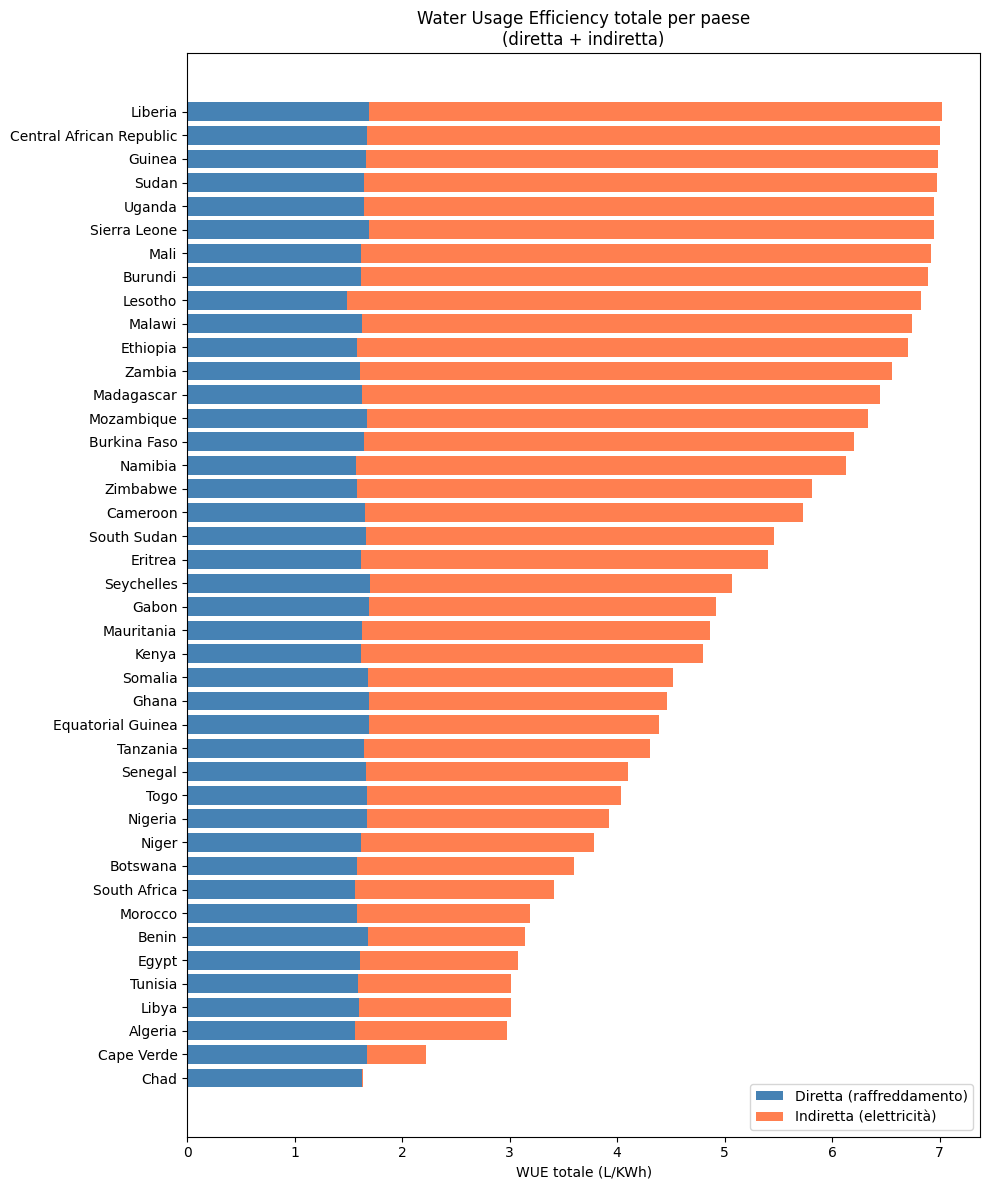

In [5]:
country_summary = df.groupby('country').agg(
    wue_direct=('WUE_FixedApproachDirect(L/KWh)', 'mean'),
    wue_indirect=('WUE_Indirect(L/KWh)', 'mean')
).reset_index()

country_summary['wue_total'] = country_summary['wue_direct'] + country_summary['wue_indirect']
country_summary = country_summary.sort_values('wue_total', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(country_summary['country'], country_summary['wue_direct'],
        label='Diretta (raffreddamento)', color='steelblue')
ax.barh(country_summary['country'], country_summary['wue_indirect'],
        left=country_summary['wue_direct'],
        label='Indiretta (elettricità)', color='coral')

ax.set_xlabel('WUE totale (L/KWh)')
ax.set_title('Water Usage Efficiency totale per paese\n(diretta + indiretta)')
ax.legend()
plt.tight_layout()
plt.savefig('../output/figures/wue_totale_per_paese.png', dpi=150)
plt.show()

### Nelle diverse regioni climatiche, quanto varia la WUE mensilmente?

Il motivo dietro questa domanda, era inizialmente quello di osservare in base alle stagioni quanto questo cambiasse. 
Il clima influenza molto la quantità di acqua che serve per rafreddare i datacenter. Intuitivamente, verrebbe da pensare che nelle regioni in cui fa più caldo, serva pià acqua e che di conseguenza non sia efficiente costruire li i i data centers. Tuttavia si potrà osservare in un altra analisi che non è perforza vero.



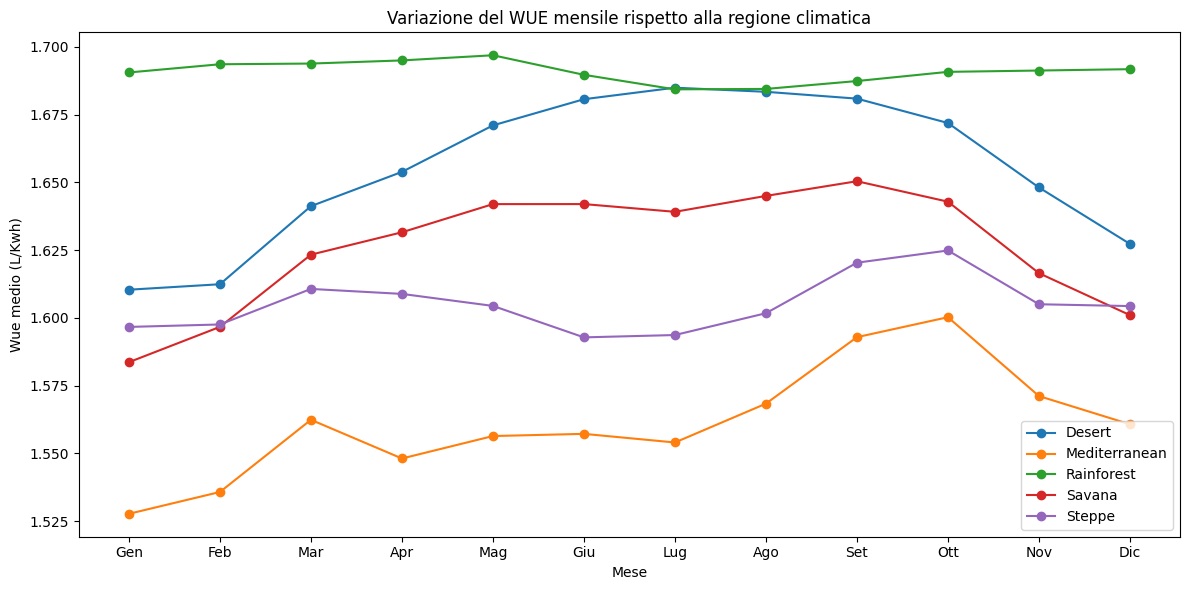

In [37]:
monthly_wue = df.groupby(['climate_region','month'])['WUE_FixedApproachDirect(L/KWh)'].mean().reset_index()

fig, ax =  plt.subplots(figsize=(12,6))
for region in monthly_wue['climate_region'].unique():
    #prendi i dati dobe le regioni sono uguali
    data_to_show = monthly_wue[monthly_wue['climate_region']==region]
    ax.plot(data_to_show['month'],data_to_show['WUE_FixedApproachDirect(L/KWh)'],marker='o',label=region)

ax.set_xlabel("Mese")
ax.set_ylabel("Wue medio (L/Kwh)")
ax.set_title("Variazione del WUE mensile rispetto alla regione climatica")
ax.legend()
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic'])
plt.tight_layout()
plt.savefig('../output/figures/wue_mensile_x_regioneclimatica.png',dpi=150)
plt.show()


### Possedere fonti rinnovabili vuol dire perforza fare un buon Water Usage Efficiency?

L'idea è che, quando si pensa a "rinnovabili", la conlusione che viene da fare è che sia sostenibile e la nostra mente magari pensa che vi sia  meno consumo idrico per produrre energia elettrica.

Il grafico realizzato però, con l'obiettivo di mettere a confronto il WUE indiretto e le diverse fonti di energia, mostrano che i paesi che hanno un altra percentuale di energia da fonti rinnovabili hanno una WUE indiretta abbastanza alta, tra i più alti del continente. 

Invece i paesi desertici che non sfruttano più di tanto energia rinnovabile possiedono una WUE indiretta più bassa.
Questo ci porta a presupporre che magari i paesi con WUE indiretta alta hanno un contributo da parte dell’idroelettrico molto importante, fonte di energia che molti paesi non possono sfruttare più di tanto.

L’ipotesi si basa sia sulla struttura geografica di paesi come il Lesotho ma anche sull’effettiva analisi della percentuale di idroelettrico che c’è nei paesi in alto a destra del grafico.

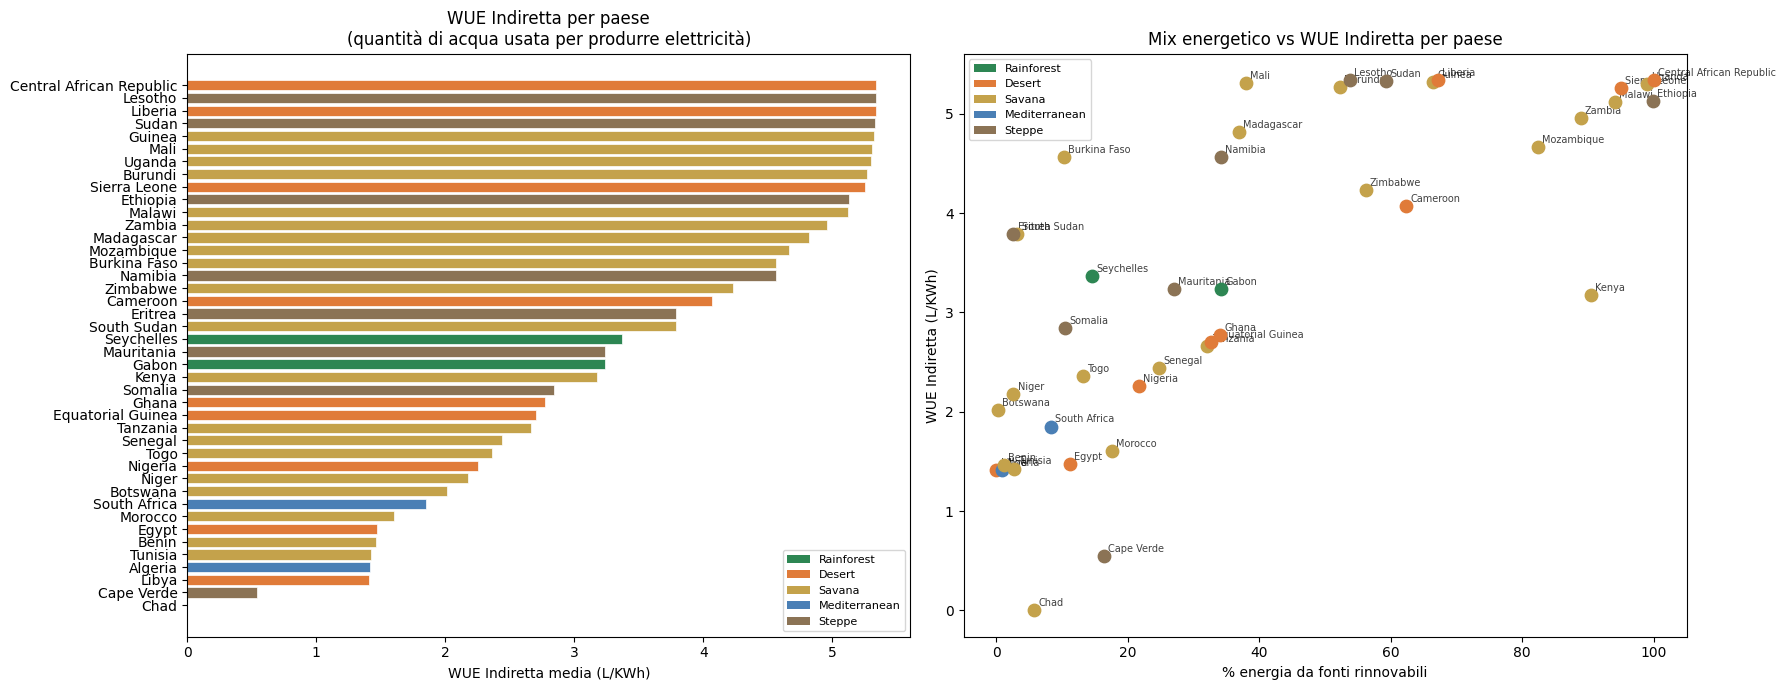

In [11]:
# Aggrego per per paese e regione climatica
country_indirect = df.groupby(['country', 'climate_region']).agg(
    wue_indirect=('WUE_Indirect(L/KWh)', 'mean'),
    renewables_share=('Total renewables - TWh', 'mean'),
    total_energy=('Total energy - TWh', 'mean')
).reset_index()

# calcolo delle percentuali 
country_indirect['renewables_pct'] = (
    country_indirect['renewables_share'] / country_indirect['total_energy'] * 100
).round(1)

country_indirect = country_indirect.sort_values('wue_indirect', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = [palette.get(r, 'gray') for r in country_indirect['climate_region']]
bars = axes[0].barh(country_indirect['country'], country_indirect['wue_indirect'],
                     color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('WUE Indiretta media (L/KWh)')
axes[0].set_title('WUE Indiretta per paese\n(quantità di acqua usata per produrre elettricità)')

# Leggenda 
legend_elements = [Patch(facecolor=c, label=r) for r, c in palette.items()]
axes[0].legend(handles=legend_elements, fontsize=8, loc='lower right')

for _, row in country_indirect.iterrows():
    color = palette.get(row['climate_region'], 'gray')
    axes[1].scatter(row['renewables_pct'], row['wue_indirect'],
                    color=color, s=80, zorder=5)
    axes[1].annotate(row['country'], (row['renewables_pct'], row['wue_indirect']),
                     fontsize=7, alpha=0.75, xytext=(3, 3),
                     textcoords='offset points')

axes[1].set_xlabel('% energia da fonti rinnovabili')
axes[1].set_ylabel('WUE Indiretta (L/KWh)')
axes[1].set_title('Mix energetico vs WUE Indiretta per paese')
axes[1].legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig('../output/figures/03_wue_indirect_per_paese.png', dpi=150)
plt.show()

### Il WUE indiretto dei paesi con il valore più alto dipende veramente dall'idroelettrico? 

La seguente analisi ce lo conferma chiaramente. I primi 5 paesi con un altra percentuale di rinnovabile hanno una componente significativa di energia idroelettrica. Li possiamo osservare nel quadrante in alto a destra del grafico sopra.

I 5 paesi che hanno WUE indiretto più basso, hanno un alta percentuale di energia proveniente da fonti non rinnovabili. Quindi, quando si considera il WUE indiretto, quest'ultimi sembrano essere più efficienti.

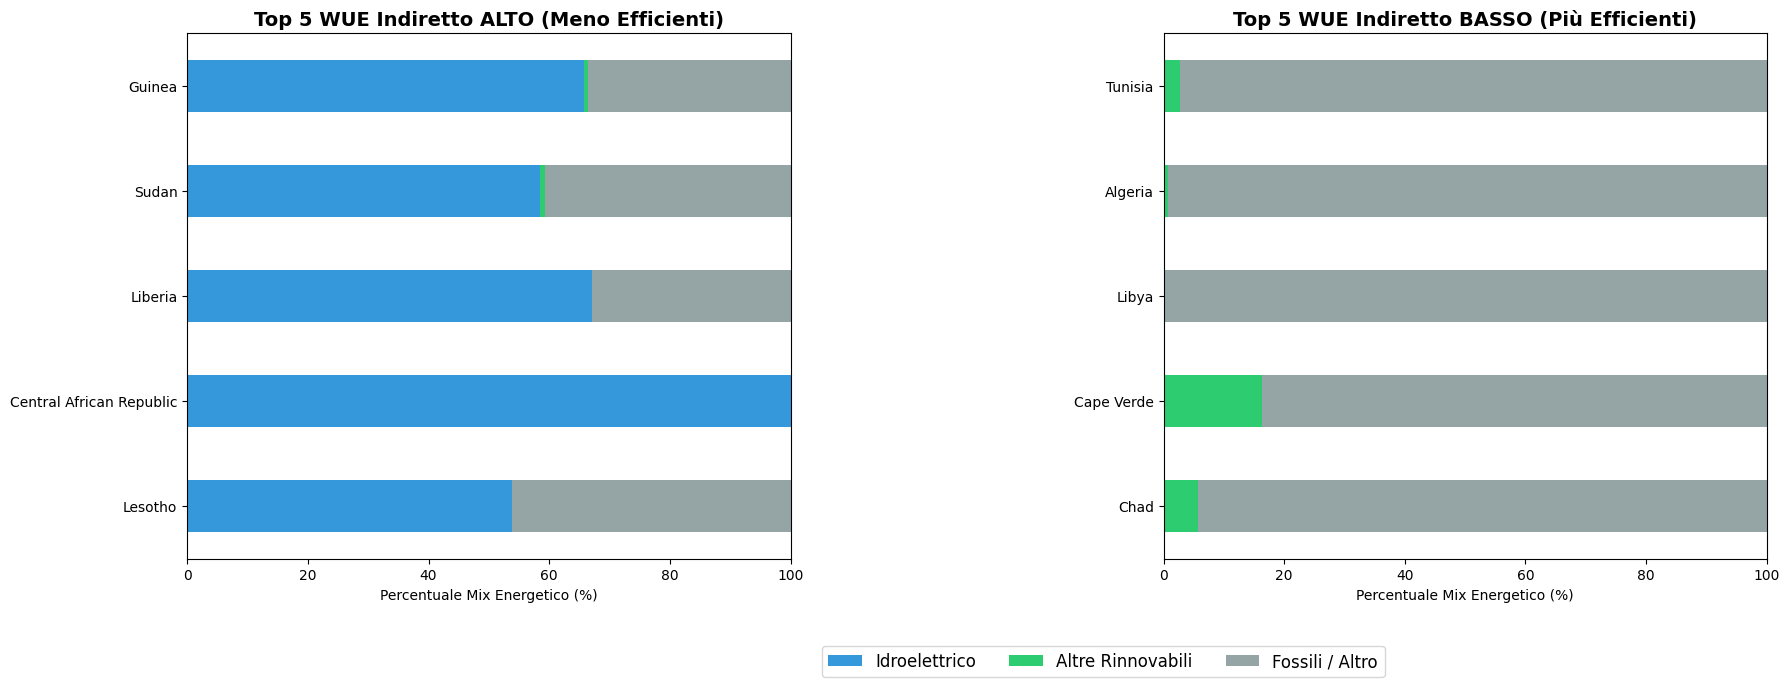

In [10]:
df['Non-Renewables - TWh'] = df['Total energy - TWh'] - df['Total renewables - TWh']
df['Other Renewables - TWh'] = df['Total renewables - TWh'] - df['Hydro consumption - TWh']

# aggregazione tramite le diverse fonti di energia
energy_mix = df.groupby('country').agg({
    'WUE_Indirect(L/KWh)': 'mean',
    'Hydro consumption - TWh': 'mean',
    'Other Renewables - TWh': 'mean',
    'Non-Renewables - TWh': 'mean',
    'Total energy - TWh': 'mean'
}).reset_index()

sources = ['Hydro consumption - TWh', 'Other Renewables - TWh', 'Non-Renewables - TWh']
for source in sources:
    energy_mix[source + ' %'] = (energy_mix[source] / energy_mix['Total energy - TWh']) * 100

top5_highWueIndirect = energy_mix.sort_values('WUE_Indirect(L/KWh)', ascending=False).head(5)
top5_lowWueIndirect = energy_mix.sort_values('WUE_Indirect(L/KWh)', ascending=True).head(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

plot_data = [
    (top5_highWueIndirect, ax1, 'Top 5 WUE Indiretto ALTO (Meno Efficienti)'),
    (top5_lowWueIndirect, ax2, 'Top 5 WUE Indiretto BASSO (Più Efficienti)')
]

colors = ['#3498db', '#2ecc71', '#95a5a6'] 
labels = ['Idroelettrico', 'Altre Rinnovabili', 'Fossili / Altro']

for data, ax, title in plot_data:
    data.set_index('country')[[s + ' %' for s in sources]].plot(
        kind='barh', stacked=True, ax=ax, color=colors, legend=False
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Percentuale Mix Energetico (%)')
    ax.set_ylabel('')

# leggenda
ax2.legend(labels, loc='upper center', bbox_to_anchor=(-0.1, -0.15), ncol=3, fontsize=12)
plt.tight_layout()
plt.show()

Le analisi fatte sono state domande che mi sono venute in mente partendo dalla prima domanda.